# Fake News Detection Pipeline

Baseline classifier using **TF-IDF + Logistic Regression** on the [ISOT Fake News Dataset](https://onlineacademiccommunity.uvic.ca/isot/).

**Steps:**
1. Load `Fake.csv` & `True.csv`, add binary labels, concatenate
2. Inspect columns, sample rows, missing values, duplicates, class distribution
3. Basic cleaning & create unified `content` column
4. TF-IDF + Logistic Regression baseline
5. Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix)
6. Save cleaned dataset for later transformer fine-tuning

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_colwidth", 120)

## 1. Load & Label the Dataset

In [2]:
df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

df_fake["label"] = 1
df_true["label"] = 0

print(f"Fake articles: {len(df_fake)}")
print(f"True articles: {len(df_true)}")

df = pd.concat([df_fake, df_true], ignore_index=True)
print(f"\nCombined dataset: {df.shape}")

Fake articles: 23481
True articles: 21417

Combined dataset: (44898, 5)


## 2. Inspect the Dataset

In [3]:
print("Column names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print(f"\nShape: {df.shape}")

Column names: ['title', 'text', 'subject', 'date', 'label']

Data types:
title      object
text       object
subject    object
date       object
label       int64
dtype: object

Shape: (44898, 5)


In [4]:
print("=== Sample Fake articles ===")
display(df[df["label"] == 1].head(3))
print("\n=== Sample True articles ===")
display(df[df["label"] == 0].head(3))

=== Sample Fake articles ===


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Securit...",News,"December 30, 2017",1



=== Sample True articles ===


,title,text,subject,date,label
23481,"As U.S. budget fight looms, Republicans flip their fiscal script","WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for ...",politicsNews,"December 31, 2017",0
23482,U.S. military to accept transgender recruits on Monday: Pentagon,WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting...,politicsNews,"December 29, 2017",0
23483,Senior U.S. Republican senator: 'Let Mr. Mueller do his job',WASHINGTON (Reuters) - The special counsel investigation of links between Russia and President Trump’s 2016 election...,politicsNews,"December 31, 2017",0


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Total missing: 0


In [6]:
dup_count = df.duplicated(subset=["title", "text"]).sum()
print(f"Duplicate rows (by title+text): {dup_count}")

Duplicate rows (by title+text): 5793


Label distribution:
label
Fake (1)    23481
True (0)    21417
Name: count, dtype: int64


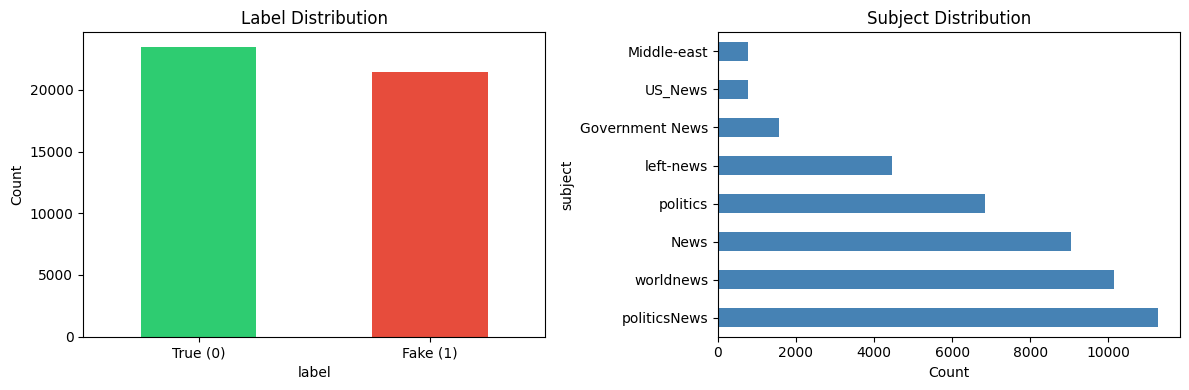

In [7]:
print("Label distribution:")
print(df["label"].value_counts().rename({0: "True (0)", 1: "Fake (1)"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["label"].value_counts().plot(kind="bar", ax=axes[0], rot=0, color=["#2ecc71", "#e74c3c"])
axes[0].set_xticklabels(["True (0)", "Fake (1)"])
axes[0].set_title("Label Distribution")
axes[0].set_ylabel("Count")

df["subject"].value_counts().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Subject Distribution")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

## 3. Cleaning & Unified Text Column

In [8]:
print(f"Rows before cleaning: {len(df)}")

df["title"] = df["title"].fillna("").astype(str).str.strip()
df["text"]  = df["text"].fillna("").astype(str).str.strip()

# Some True.csv articles start with "CITY (Reuters) -" prefix; keep it as-is for now
df["content"] = (df["title"] + " " + df["text"]).str.strip()

df = df[df["content"].str.len() > 0].copy()
print(f"Rows after dropping empty content: {len(df)}")

df = df.drop_duplicates(subset=["title", "text"]).reset_index(drop=True)
print(f"Rows after dropping duplicates: {len(df)}")

df["word_count"] = df["content"].str.split().str.len()
print(f"\nWord count stats:")
print(df["word_count"].describe().to_string())

Rows before cleaning: 44898
Rows after dropping empty content: 44898
Rows after dropping duplicates: 39103

Word count stats:
count    39103.000000
mean       410.448968
std        315.091516
min          2.000000
25%        220.000000
50%        378.000000
75%        521.000000
max       8148.000000


In [9]:
print("Sample content (Fake):")
print(df.loc[df["label"] == 1, "content"].iloc[0][:500])
print("\n" + "="*80)
print("\nSample content (True):")
print(df.loc[df["label"] == 0, "content"].iloc[0][:500])

Sample content (Fake):
Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a


Sample content (True):
As U.S. budget fight looms, Republicans flip their fiscal script WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation

## 4. TF-IDF + Logistic Regression Baseline

In [10]:
X = df["content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train label distribution:\n{y_train.value_counts().to_string()}")
print(f"Test  label distribution:\n{y_test.value_counts().to_string()}")

Train size: 31282, Test size: 7821
Train label distribution:
label
0    16957
1    14325
Test  label distribution:
label
0    4239
1    3582


In [11]:
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2,
    max_df=0.95,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

TF-IDF matrix shape: (31282, 50000)


In [12]:
model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print("Model training complete.")

Model training complete.


## 5. Evaluation

In [13]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["True", "Fake"]))

Accuracy:  0.9857
Precision: 0.9909
Recall:    0.9777
F1 Score:  0.9843

Classification Report:
              precision    recall  f1-score   support

        True       0.98      0.99      0.99      4239
        Fake       0.99      0.98      0.98      3582

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



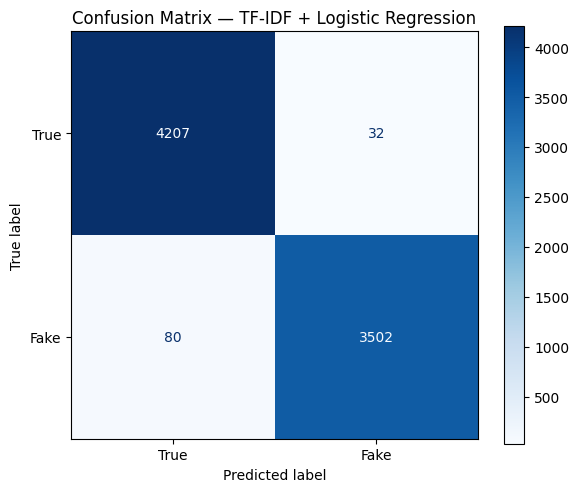

In [14]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["True", "Fake"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

### Top 20 TF-IDF Features per Class

Logistic Regression coefficients tell us which words push the prediction toward each class:
- **Positive coefficients** → Fake (label = 1)
- **Negative coefficients** → True (label = 0)

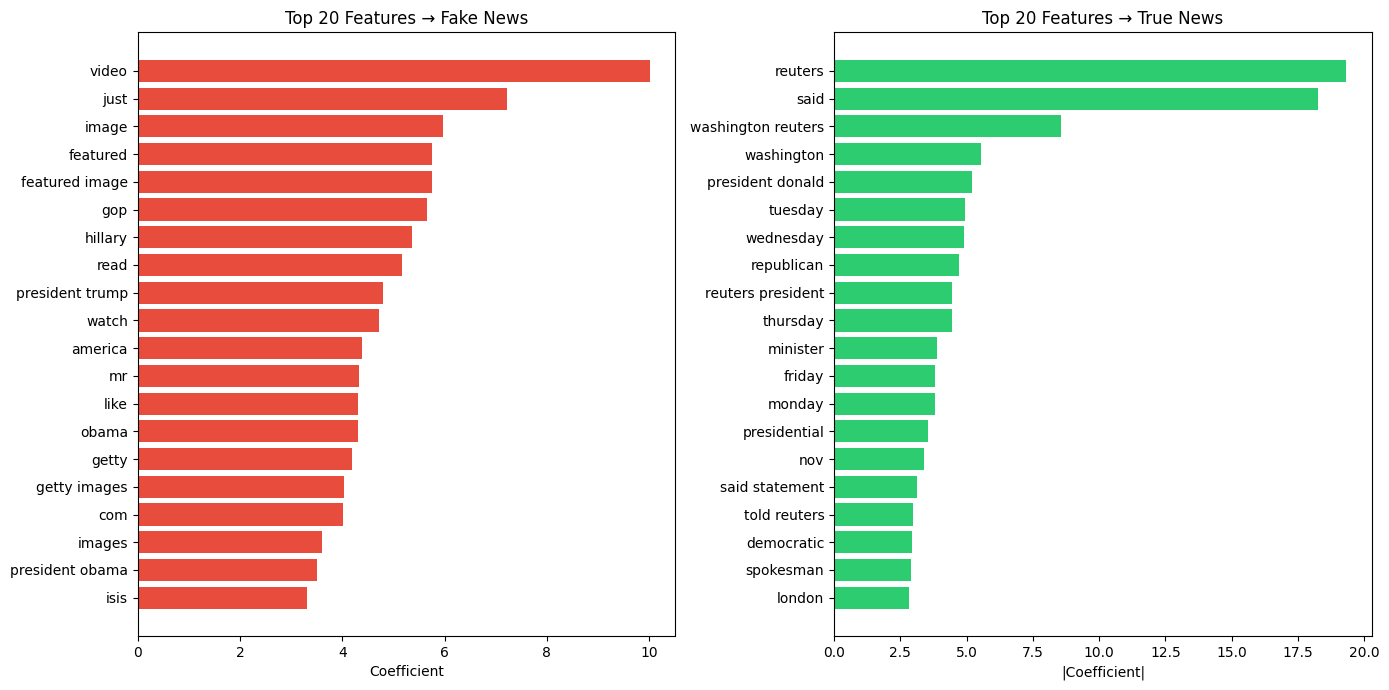


Rank  Fake News Feature                Score    True News Feature                Score
------------------------------------------------------------------------------------------
1     video                          10.0106    reuters                        19.3227
2     just                            7.2173    said                           18.2555
3     image                           5.9741    washington reuters              8.5563
4     featured                        5.7449    washington                      5.5498
5     featured image                  5.7446    president donald                5.1887
6     gop                             5.6571    tuesday                         4.9489
7     hillary                         5.3559    wednesday                       4.8827
8     read                            5.1615    republican                      4.7252
9     president trump                 4.7990    reuters president               4.4606
10    watch                           

In [ ]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = model.coef_[0]

top_k = 20

# Positive coefs → Fake (label=1), Negative coefs → True (label=0)
top_fake_idx = np.argsort(coefs)[-top_k:][::-1]
top_true_idx = np.argsort(coefs)[:top_k]

top_fake_words  = feature_names[top_fake_idx]
top_fake_scores = coefs[top_fake_idx]
top_true_words  = feature_names[top_true_idx]
top_true_scores = coefs[top_true_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(range(top_k), top_fake_scores[::-1], color="#e74c3c")
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels(top_fake_words[::-1])
axes[0].set_xlabel("Coefficient")
axes[0].set_title(f"Top {top_k} Features → Fake News")

axes[1].barh(range(top_k), np.abs(top_true_scores[::-1]), color="#2ecc71")
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels(top_true_words[::-1])
axes[1].set_xlabel("|Coefficient|")
axes[1].set_title(f"Top {top_k} Features → True News")

plt.tight_layout()
plt.show()

print(f"\n{'Rank':<6}{'Fake News Feature':<30}{'Score':>8}    {'True News Feature':<30}{'Score':>8}")
print("-" * 90)
for i in range(top_k):
    print(f"{i+1:<6}{top_fake_words[i]:<30}{top_fake_scores[i]:>8.4f}    {top_true_words[i]:<30}{abs(top_true_scores[i]):>8.4f}")

## 6. Save Cleaned Dataset

In [16]:
import os
os.makedirs("data", exist_ok=True)

save_cols = ["title", "text", "content", "subject", "date", "label"]
df[save_cols].to_csv("data/fake_news_full_clean.csv", index=False)
print(f"Saved data/fake_news_full_clean.csv  ({len(df)} rows, {len(save_cols)} cols)")

Saved data/fake_news_full_clean.csv  (39103 rows, 6 cols)


## Summary

| Item | Detail |
|------|--------|
| Dataset | ISOT Fake News (`Fake.csv` + `True.csv`) |
| Labels | True → 0, Fake → 1 |
| Text feature | `title` + `text` → `content` |
| Vectorizer | TF-IDF (50k features, unigrams + bigrams, min_df=2, max_df=0.95) |
| Model | Logistic Regression (C=1.0, max_iter=1000) |
| Split | 80% train / 20% test (stratified) |
| Output | `data/fake_news_full_clean.csv` for downstream transformer training |